In [3]:
%autoreload 2

In [2]:
%reload_ext autoreload
import os, sys, ast
import numpy as np
import pandas as pd
import seaborn as sns
import tifffile

import matplotlib.pyplot as plt
from matplotlib import gridspec, rcParams
from fish import Gafftopsail
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import utils, barcode
rcParams['font.size'] = 10

In [3]:
#load atlas
template_path = "C:\Data\MapZBrainATLAS\T_AVG_HuCD.tif"
template = tifffile.imread(template_path)

<>:2: SyntaxWarning: invalid escape sequence '\D'
<>:2: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Zichen\AppData\Local\Temp\ipykernel_35240\4158968567.py:2: SyntaxWarning: invalid escape sequence '\D'
  template_path = "C:\Data\MapZBrainATLAS\T_AVG_HuCD.tif"


In [21]:
def plot_all(grating_responses, dot_responses):
    fig, ax = plt.subplots(1, 3, dpi = 600, figsize = (20, 10))

    #only plot visually responsive neurons that have been somewhat barrcoded
    barred_gratings = list(set(grating_responses.index[(grating_responses.filter(like="barred_").any(axis=1)) & (grating_responses["DSI2"] >0)]))
    ax_imshow = ax[2]
    ax_imshow.imshow(template[170], vmin = 0, vmax = 800, cmap = 'Greys')
    ax_imshow.scatter(grating_responses.loc[barred_gratings, 'xpos'], grating_responses.loc[barred_gratings, 'ypos'],color = 'limegreen', s = 5,alpha= 0.5, marker = '.')

    barred_dot = list(set(dot_responses.index[(dot_responses.filter(like="barred_").any(axis=1))]))
    ax_imshow_dot = ax[2]
    ax_imshow_dot.imshow(template[170], vmin = 0, vmax = 800, cmap = 'Greys')
    ax_imshow_dot.scatter(dot_responses.loc[barred_dot, 'xpos'], dot_responses.loc[barred_dot, 'ypos'],color = 'hotpink', s = 1,alpha=  0.5, marker = '.')

    barred_overlap = list(set(barred_dot) & set(barred_gratings))
    ax_overlap = ax[2]
    ax_overlap.imshow(template[170], vmin = 0, vmax = 800, cmap = 'Greys')
    ax_overlap.scatter(grating_responses.loc[barred_overlap, 'xpos'], grating_responses.loc[barred_overlap, 'ypos'],color = 'grey', s = 1,alpha=  1, marker = '.')

    ax_overlap.set_title(f"{round(len(barred_overlap)/len(barred_gratings)*100)}%grating\n{round(len(barred_overlap)/len(barred_dot)*100)}%dot")
    return fig

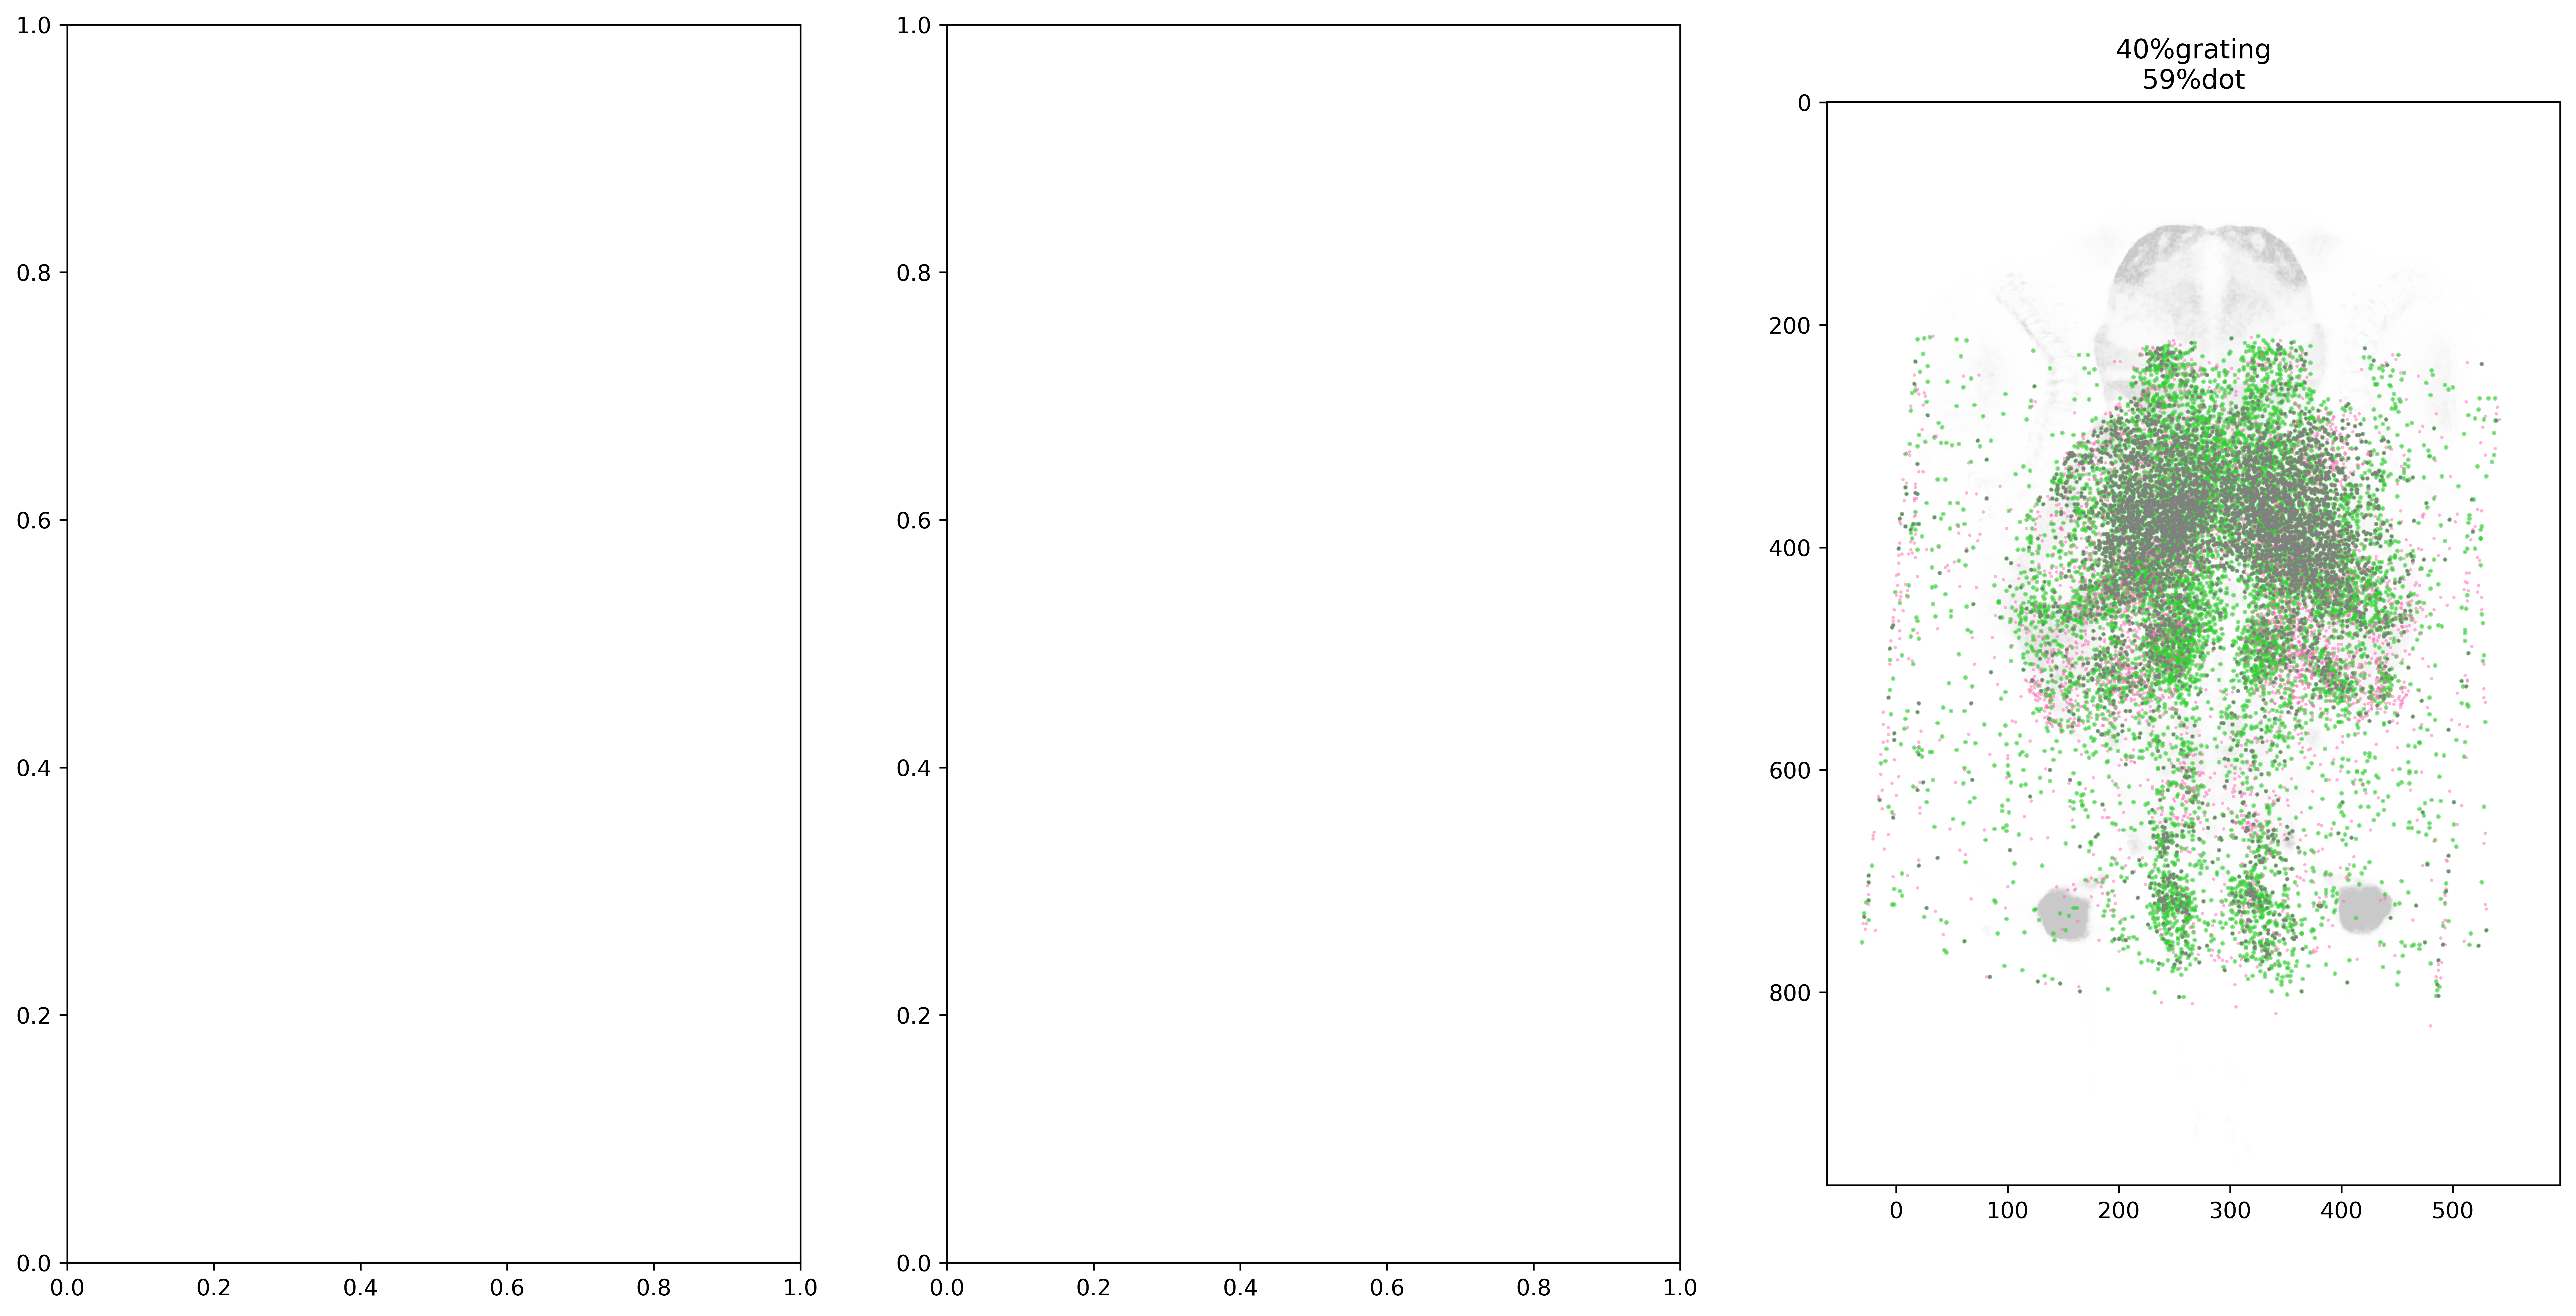

In [22]:
paths = [r"C:\Data\Imaging\250912_overlap\fish3",
r"C:\Data\Imaging\250912_overlap\fish2_2",
         r"C:\Data\Imaging\250912_overlap\fish5_2",
         r"C:\Data\Imaging\250912_overlap\fish9",
r"C:\Data\Imaging\250912_overlap\fish8",
         r"C:\Data\Imaging\250912_overlap\fish15",
r"C:\Data\Imaging\250912_overlap\fish13",
r"C:\Data\Imaging\250912_overlap\fish14"]
paths =      [r"C:\Data\Imaging\251021_dotsweep\fish5_overlap",
 r"C:\Data\Imaging\251021_dotsweep\fish4_overlap",
 r"C:\Data\Imaging\251021_dotsweep\fish3_overlap"]
paths = [   r"C:\Data\Imaging\251224_overlap\fish3_HB",
r"C:\Data\Imaging\251224_overlap\fish5",
r"C:\Data\Imaging\251224_overlap\fish5_HB",
r"C:\Data\Imaging\251224_overlap\fish1",
r"C:\Data\Imaging\251224_overlap\fish1_HB",
r"C:\Data\Imaging\251224_overlap\fish2",
r"C:\Data\Imaging\251224_overlap\fish2_HB",
r"C:\Data\Imaging\251224_overlap\fish3"]

grating_responses = []
dot_responses = []
for path in paths:
    grating_response = pd.read_csv(path + '//analyze_results//grating_responses.csv', index_col = 0)
    dot_response = pd.read_csv(path + '//analyze_results//dot_responses.csv', index_col = 0)
    new_poses = []
    neuron_count = 0
    for plane in range(3):
        new_pos = pd.read_csv(path + f'//Imaging//plane_{plane}//Alignment//new_pos.csv', converters={"regions": ast.literal_eval})
        # stat = np.load(path + f'//Imaging//plane_{plane}//'+ 'stat.npy', allow_pickle=True)
        # avg_xpos = np.array([np.mean(cell['ypix']) for cell in stat])
        # avg_ypos = np.array([np.mean(cell['xpix']) for cell in stat])
        # avg_zpos = np.array([plane] * len(avg_xpos))
        # new_pos = pd.DataFrame(data = np.array([avg_xpos, avg_ypos, avg_zpos]).T,
        #                                    columns = ['xpos', 'ypos', 'zpos'],
        #                                    index = np.add(range(len(avg_xpos)), neuron_count))
        # neuron_count += len(avg_xpos)
        new_poses.append(new_pos)
    new_poses = pd.concat(new_poses, ignore_index = True)
    grating_response = pd.concat([grating_response, new_poses], ignore_index = False, axis = 1)
    grating_response.loc[:, 'fish_id'] = path
    grating_responses.append(grating_response)
    dot_response = pd.concat([dot_response, new_poses], ignore_index = False, axis = 1)
    dot_response.loc[:, 'fish_id'] = path
    dot_responses.append(dot_response)

grating_responses = pd.concat(grating_responses).reset_index(drop = False)
dot_responses = pd.concat(dot_responses).reset_index(drop = False)

fig = plot_all(grating_responses, dot_responses)
plt.savefig(r"C:\Data\Imaging\251224_overlap\All_imaging//distribution.png")
plt.show()
plt.close()